# Audio Utilities

In [3]:
#| default_exp audio.utils

In [4]:
#| hide
%load_ext autoreload
%autoreload 2
from nbdev.showdoc import *

In [5]:
#| export
import torch
from matplotlib import pyplot as plt
import torchaudio

In [6]:
#| export
def plot_waveform(waveform, sample_rate, title="Waveform", xlim=None, ylim=None):
   waveform = waveform.numpy()
   num_channels, num_frames = waveform.shape
   time_axis = torch.arange(0, num_frames) / sample_rate

   figure, axes = plt.subplots(num_channels, 1)
   if num_channels == 1:
       axes = [axes]
   for c in range(num_channels):
       axes[c].plot(time_axis, waveform[c], linewidth=1)
       axes[c].grid(True)
       if num_channels > 1:
           axes[c].set_ylabel(f"Channel {c+1}")
       if xlim:
           axes[c].set_xlim(xlim)
       if ylim:
           axes[c].set_ylim(ylim)
   figure.suptitle(title)
   plt.show(block=False)
   
def plot_specgram(waveform, sample_rate, title="Spectrogram", xlim=None):
  waveform = waveform.numpy()

  num_channels, num_frames = waveform.shape
  time_axis = torch.arange(0, num_frames) / sample_rate

  figure, axes = plt.subplots(num_channels, 1)
  if num_channels == 1:
    axes = [axes]
  for c in range(num_channels):
    axes[c].specgram(waveform[c], Fs=sample_rate)
    if num_channels > 1:
      axes[c].set_ylabel(f'Channel {c+1}')
    if xlim:
      axes[c].set_xlim(xlim)
  figure.suptitle(title)
  plt.show(block=False)


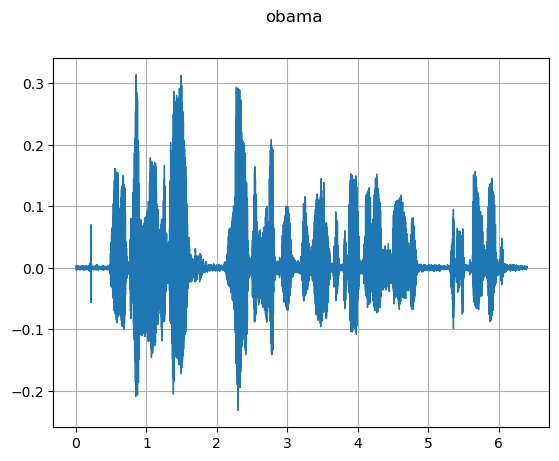

In [10]:
wav, sr = torchaudio.load("../data/audio/obama.wav")
plot_waveform(wav,sr, title='obama')

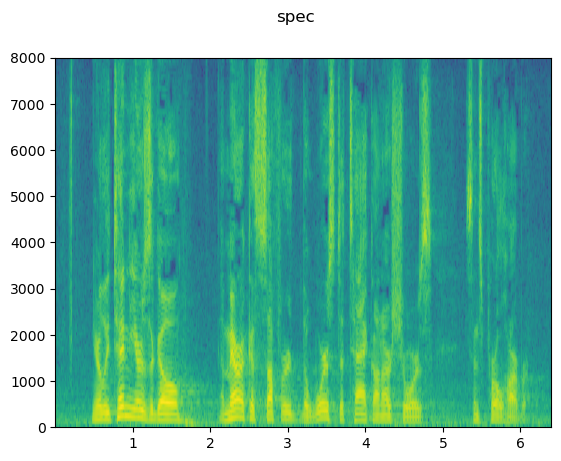

In [8]:
plot_specgram(wav, sr, title='spec')

In [ ]:
#| hide
import nbdev; nbdev.nbdev_export()